# 02 — Modélisation & Évaluation
## Diabetes Prediction — Comparaison de 5 modèles

**Objectif** : Entraîner 5 modèles, analyser chacun en profondeur (overfitting/underfitting,
métriques par seuil, matrice de confusion, courbe ROC), puis comparer et sélectionner
le meilleur selon : **Recall max + Specificité ≥ 50% + pas d'overfitting**.

## 1. Imports & Configuration

In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, accuracy_score
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from src.preprocessing import load_data, prepare_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
THRESHOLDS   = [0.5, 0.4, 0.3, 0.2, 0.1]
MIN_SPEC     = 0.5   # Specificite minimum exigee
OVERFIT_SEUIL = 0.1  # Ecart AUC train-test max tolere
print('Imports OK')




Imports OK


## 2. Chargement des données & Splits

In [5]:
import sys
sys.path.append('..')

from src.preprocessing import load_data, prepare_data

df = load_data('../data/diabetes_prediction_dataset.csv')

X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = prepare_data(df)

print('=' * 55)
print('REPARTITION DES DONNEES')
print('=' * 55)
print(f'Train      : {X_train.shape[0]:>6} exemples | Diabetiques: {y_train.sum():>4} ({y_train.mean()*100:.1f}%)')
print(f'Validation : {X_val.shape[0]:>6} exemples | Diabetiques: {y_val.sum():>4} ({y_val.mean()*100:.1f}%)')
print(f'Test       : {X_test.shape[0]:>6} exemples | Diabetiques: {y_test.sum():>4} ({y_test.mean()*100:.1f}%)')
print(f'Total      : {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:>6} exemples')

Dataset chargé : 100000 lignes, 9 colonnes
Diabétiques    : 8500 (8.5%)
Non-diabét.    : 91500 (91.5%)

Train      : 68000 exemples | Diabétiques: 5780 (8.5%)
Validation : 12000 exemples   | Diabétiques: 1020 (8.5%)
Test       : 20000 exemples  | Diabétiques: 1700 (8.5%)
Total      : 100000
REPARTITION DES DONNEES
Train      :  68000 exemples | Diabetiques: 5780 (8.5%)
Validation :  12000 exemples | Diabetiques: 1020 (8.5%)
Test       :  20000 exemples | Diabetiques: 1700 (8.5%)
Total      : 100000 exemples


## 3. Fonctions utilitaires

In [6]:
def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        return None
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    recall      = tp / (tp + fn)       if (tp + fn) > 0       else 0
    specificity = tn / (tn + fp)       if (tn + fp) > 0       else 0
    precision   = tp / (tp + fp)       if (tp + fp) > 0       else 0
    f1          = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
    return dict(Accuracy=round(accuracy,4), Recall=round(recall,4),
                Specificite=round(specificity,4), Precision=round(precision,4),
                F1=round(f1,4), TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn))

def plot_confusion_matrix_medical(y_true, y_proba, threshold, model_name, ax):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ax.imshow(cm, cmap='Blues')
    labels = [['TN', 'FP'], ['FN (CRITIQUE)', 'TP']]
    for i in range(2):
        for j in range(2):
            color = 'red' if (i==1 and j==0) else ('white' if cm[i,j] > cm.max()/2 else 'black')
            ax.text(j, i, f'{cm[i,j]}\n{labels[i][j]}',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold', color=color)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Predit: No','Predit: Yes'])
    ax.set_yticklabels(['Reel: No','Reel: Yes'])
    ax.set_title(f'{model_name}\nSeuil={threshold}', fontsize=10)

def plot_threshold_curves(y_true, y_proba, model_name, ax):
    recalls  = [compute_metrics(y_true, y_proba, t)['Recall']      for t in THRESHOLDS]
    specs    = [compute_metrics(y_true, y_proba, t)['Specificite'] for t in THRESHOLDS]
    f1s      = [compute_metrics(y_true, y_proba, t)['F1']          for t in THRESHOLDS]
    ax.plot(THRESHOLDS, recalls, marker='o', color='red',       label='Recall')
    ax.plot(THRESHOLDS, specs,   marker='s', color='blue',      label='Specificite')
    ax.plot(THRESHOLDS, f1s,     marker='^', color='green',     label='F1-Score')
    ax.axhline(MIN_SPEC, color='gray', linestyle='--', label=f'Min Spec={MIN_SPEC}')
    ax.set_xlabel('Seuil de decision')
    ax.set_ylabel('Score')
    ax.set_title(f'Impact du seuil — {model_name}')
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

def print_threshold_table(y_true, y_proba, model_name):
    print(f'\n{model_name} — Metriques par seuil')
    print(f"{'Seuil':<8} {'Accuracy':<11} {'Recall':<10} {'Specificite':<14} {'Precision':<12} {'F1':<8} {'TP':<6} {'FP':<6} {'FN':<6} {'TN'}")
    print('-' * 85)
    for t in THRESHOLDS:
        m = compute_metrics(y_true, y_proba, t)
        flag = ' <- Spec>=50%' if m['Specificite'] >= MIN_SPEC else ''
        print(f"{t:<8.2f} {m['Accuracy']:<11.4f} {m['Recall']:<10.4f} {m['Specificite']:<14.4f} {m['Precision']:<12.4f} {m['F1']:<8.4f} {m['TP']:<6} {m['FP']:<6} {m['FN']:<6} {m['TN']}{flag}")

def find_best_threshold(y_true, y_proba):
    candidats = []
    for t in THRESHOLDS:
        m = compute_metrics(y_true, y_proba, t)
        if m['Specificite'] >= MIN_SPEC:
            candidats.append((t, m))
    if not candidats:
        return None, None
    candidats.sort(key=lambda x: x[1]['Recall'], reverse=True)
    return candidats[0]

def overfitting_status(auc_train, auc_test):
    ecart = auc_train - auc_test
    if ecart > OVERFIT_SEUIL:
        return f'OVERFITTING (ecart={ecart:.3f})'
    elif auc_test < 0.6:
        return f'UNDERFITTING (AUC test={auc_test:.3f})'
    else:
        return f'OK (ecart={ecart:.3f})'

print('Fonctions utilitaires chargees.')

Fonctions utilitaires chargees.


## 4. Définition des 5 modèles

In [7]:
models = {
    'LogisticRegression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=100, scale_pos_weight=10,
        random_state=42, eval_metric='logloss'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42)
}

# Entrainement
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} entraine.')

LogisticRegression entraine.
RandomForest entraine.
XGBoost entraine.
KNN entraine.
DecisionTree entraine.


---
## MODÈLE 1 : Logistic Regression
Modèle linéaire simple, rapide, interprétable. Bon point de départ.

In [8]:
MODEL_NAME = 'LogisticRegression'
model      = models[MODEL_NAME]
y_proba_lr = model.predict_proba(X_test)[:, 1]

# AUC Train / Val / Test
auc_train_lr = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_val_lr   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
auc_test_lr  = roc_auc_score(y_test,  y_proba_lr)
acc_train_lr = accuracy_score(y_train, model.predict(X_train))
acc_val_lr   = accuracy_score(y_val,   model.predict(X_val))
acc_test_lr  = accuracy_score(y_test,  model.predict(X_test))

print('=' * 55)
print(f'LOGISTIC REGRESSION — Overfitting/Underfitting')
print('=' * 55)
print(f'Accuracy  : Train={acc_train_lr:.4f} | Val={acc_val_lr:.4f} | Test={acc_test_lr:.4f}')
print(f'AUC-ROC   : Train={auc_train_lr:.4f} | Val={auc_val_lr:.4f} | Test={auc_test_lr:.4f}')
print(f'Statut    : {overfitting_status(auc_train_lr, auc_test_lr)}')

LOGISTIC REGRESSION — Overfitting/Underfitting
Accuracy  : Train=0.8868 | Val=0.8868 | Test=0.8885
AUC-ROC   : Train=0.9620 | Val=0.9629 | Test=0.9629
Statut    : OK (ecart=-0.001)


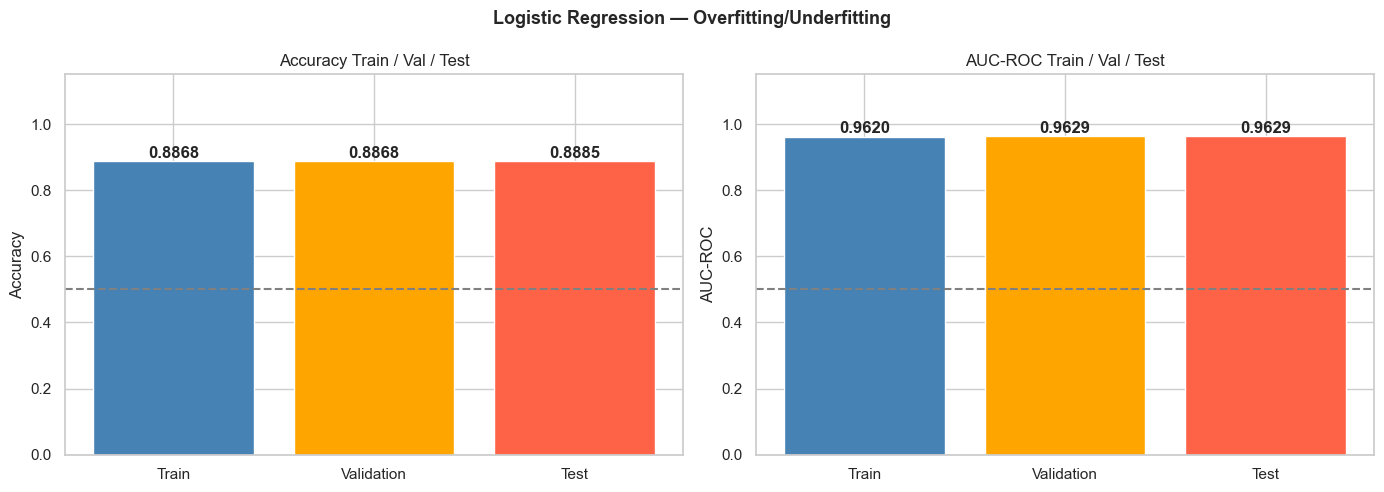

In [9]:
# Graphique Accuracy + AUC Train/Val/Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Train', 'Validation', 'Test']

axes[0].bar(categories, [acc_train_lr, acc_val_lr, acc_test_lr],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy Train / Val / Test')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([acc_train_lr, acc_val_lr, acc_test_lr]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(categories, [auc_train_lr, auc_val_lr, auc_test_lr],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC-ROC Train / Val / Test')
axes[1].set_ylabel('AUC-ROC')
axes[1].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([auc_train_lr, auc_val_lr, auc_test_lr]):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Logistic Regression — Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Tableau metriques par seuil
print_threshold_table(y_test, y_proba_lr, 'Logistic Regression')


Logistic Regression — Metriques par seuil
Seuil    Accuracy    Recall     Specificite    Precision    F1       TP     FP     FN     TN
-------------------------------------------------------------------------------------
0.50     0.8885      0.8918     0.8882         0.4256       0.5762   1516   2046   184    16254 <- Spec>=50%
0.40     0.8567      0.9218     0.8507         0.3644       0.5223   1567   2733   133    15567 <- Spec>=50%
0.30     0.8164      0.9471     0.8043         0.3101       0.4672   1610   3582   90     14718 <- Spec>=50%
0.20     0.7611      0.9653     0.7421         0.2580       0.4072   1641   4719   59     13581 <- Spec>=50%
0.10     0.6674      0.9871     0.6377         0.2019       0.3353   1678   6631   22     11669 <- Spec>=50%


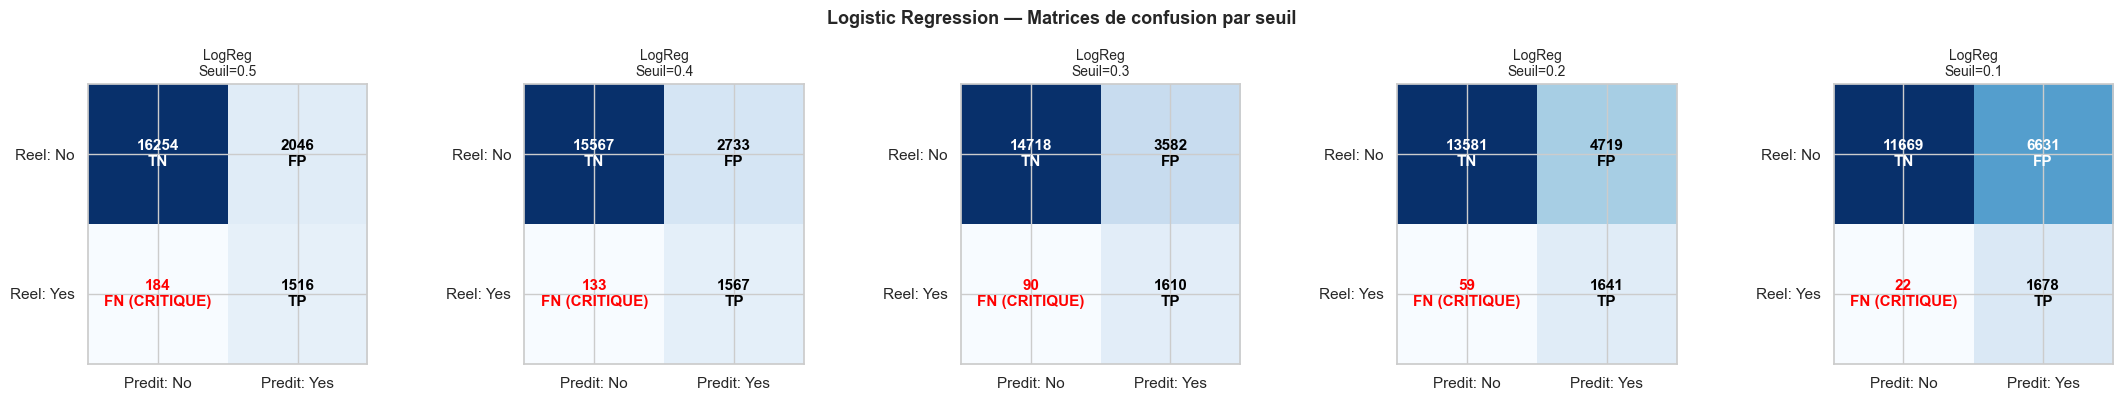

In [11]:
# Matrices de confusion pour chaque seuil
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j, thresh in enumerate(THRESHOLDS):
    plot_confusion_matrix_medical(y_test, y_proba_lr, thresh, f'LogReg', axes[j])
plt.suptitle('Logistic Regression — Matrices de confusion par seuil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

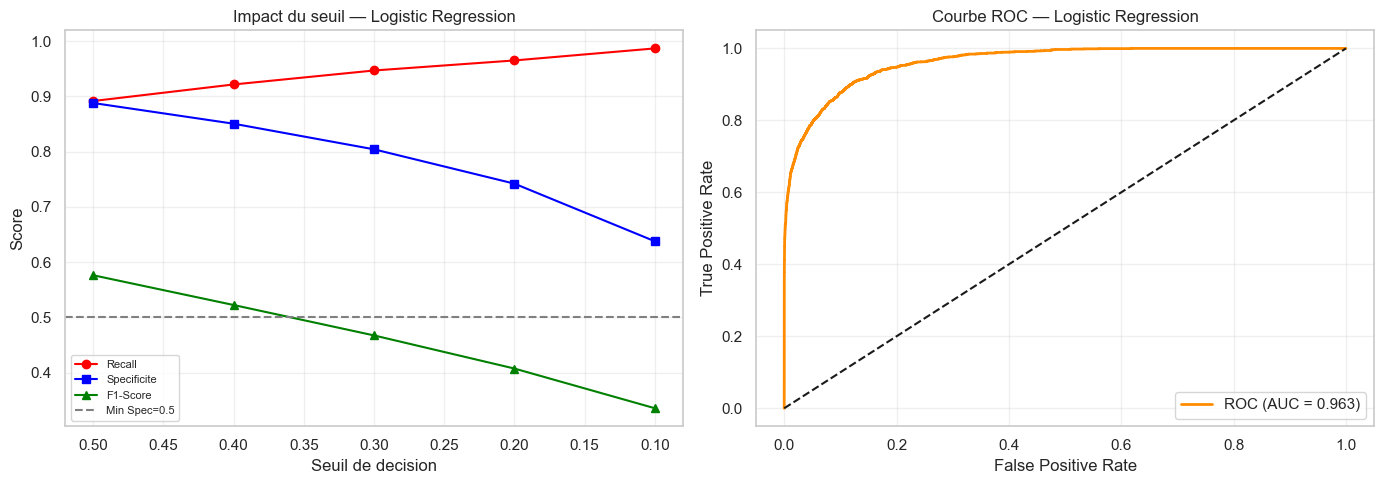

In [12]:
# Courbe seuil + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_threshold_curves(y_test, y_proba_lr, 'Logistic Regression', axes[0])

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr_lr, tpr_lr, color='darkorange', linewidth=2,
             label=f'ROC (AUC = {auc_test_lr:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — Logistic Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Meilleur seuil Logistic Regression
best_thresh_lr, best_metrics_lr = find_best_threshold(y_test, y_proba_lr)
if best_thresh_lr:
    print(f'Meilleur seuil (Spec>={MIN_SPEC}) : {best_thresh_lr}')
    print(f'  Recall      = {best_metrics_lr["Recall"]:.4f}')
    print(f'  Specificite = {best_metrics_lr["Specificite"]:.4f}')
    print(f'  F1-Score    = {best_metrics_lr["F1"]:.4f}')
    print(f'  TP={best_metrics_lr["TP"]} | FN={best_metrics_lr["FN"]} (CRITIQUE) | FP={best_metrics_lr["FP"]} | TN={best_metrics_lr["TN"]}')
else:
    print('Aucun seuil ne satisfait Specificite >= 50%')
    best_thresh_lr   = 0.5
    best_metrics_lr  = compute_metrics(y_test, y_proba_lr, 0.5)

Meilleur seuil (Spec>=0.5) : 0.1
  Recall      = 0.9871
  Specificite = 0.6377
  F1-Score    = 0.3353
  TP=1678 | FN=22 (CRITIQUE) | FP=6631 | TN=11669


---
## MODÈLE 2 : Random Forest
Ensemble d'arbres de décision. Robuste, gère bien les données déséquilibrées avec `class_weight='balanced'`.

In [14]:
MODEL_NAME = 'RandomForest'
model      = models[MODEL_NAME]
y_proba_rf = model.predict_proba(X_test)[:, 1]

auc_train_rf = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_val_rf   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
auc_test_rf  = roc_auc_score(y_test,  y_proba_rf)
acc_train_rf = accuracy_score(y_train, model.predict(X_train))
acc_val_rf   = accuracy_score(y_val,   model.predict(X_val))
acc_test_rf  = accuracy_score(y_test,  model.predict(X_test))

print('=' * 55)
print('RANDOM FOREST — Overfitting/Underfitting')
print('=' * 55)
print(f'Accuracy  : Train={acc_train_rf:.4f} | Val={acc_val_rf:.4f} | Test={acc_test_rf:.4f}')
print(f'AUC-ROC   : Train={auc_train_rf:.4f} | Val={auc_val_rf:.4f} | Test={auc_test_rf:.4f}')
print(f'Statut    : {overfitting_status(auc_train_rf, auc_test_rf)}')

RANDOM FOREST — Overfitting/Underfitting
Accuracy  : Train=0.9991 | Val=0.9695 | Test=0.9689
AUC-ROC   : Train=1.0000 | Val=0.9645 | Test=0.9612
Statut    : OK (ecart=0.039)


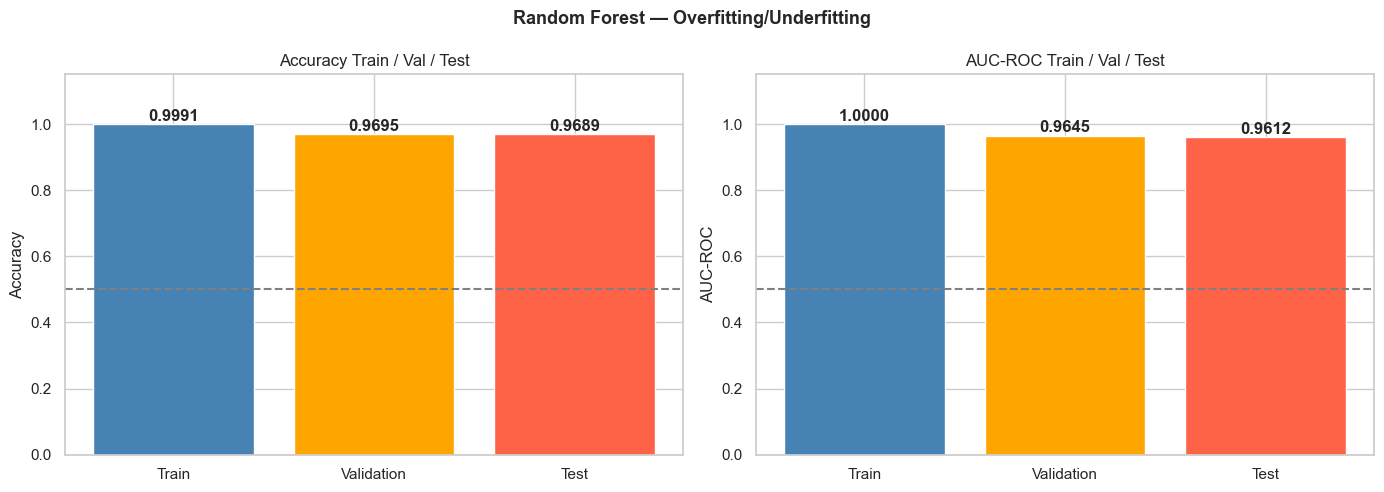

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Train', 'Validation', 'Test']

axes[0].bar(categories, [acc_train_rf, acc_val_rf, acc_test_rf],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy Train / Val / Test')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([acc_train_rf, acc_val_rf, acc_test_rf]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(categories, [auc_train_rf, auc_val_rf, auc_test_rf],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC-ROC Train / Val / Test')
axes[1].set_ylabel('AUC-ROC')
axes[1].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([auc_train_rf, auc_val_rf, auc_test_rf]):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Random Forest — Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print_threshold_table(y_test, y_proba_rf, 'Random Forest')


Random Forest — Metriques par seuil
Seuil    Accuracy    Recall     Specificite    Precision    F1       TP     FP     FN     TN
-------------------------------------------------------------------------------------
0.50     0.9690      0.6918     0.9948         0.9245       0.7914   1176   96     524    18204 <- Spec>=50%
0.40     0.9660      0.7147     0.9894         0.8623       0.7816   1215   194    485    18106 <- Spec>=50%
0.30     0.9583      0.7488     0.9778         0.7577       0.7533   1273   407    427    17893 <- Spec>=50%
0.20     0.9447      0.8006     0.9581         0.6396       0.7111   1361   767    339    17533 <- Spec>=50%
0.10     0.9106      0.8765     0.9138         0.4857       0.6250   1490   1578   210    16722 <- Spec>=50%


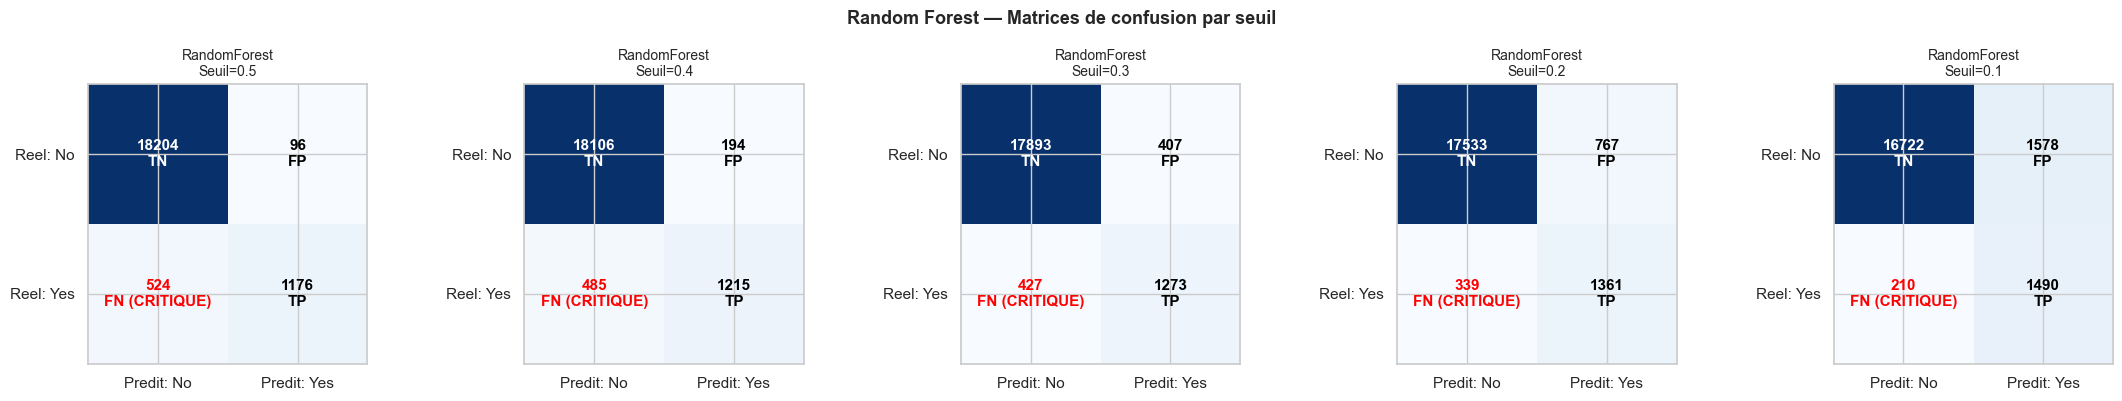

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j, thresh in enumerate(THRESHOLDS):
    plot_confusion_matrix_medical(y_test, y_proba_rf, thresh, 'RandomForest', axes[j])
plt.suptitle('Random Forest — Matrices de confusion par seuil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

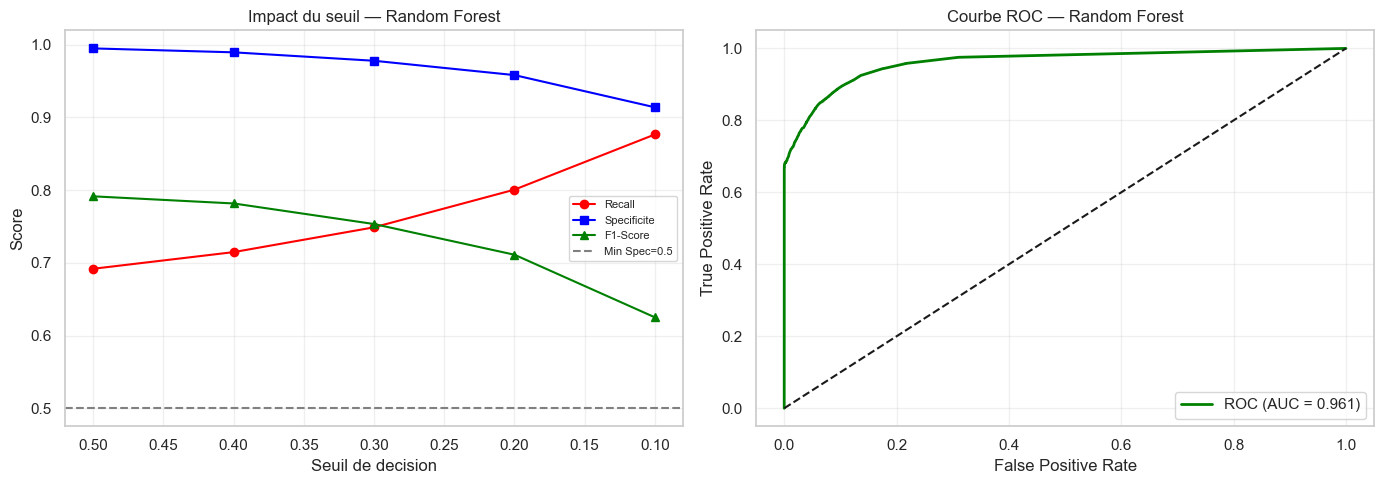

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_threshold_curves(y_test, y_proba_rf, 'Random Forest', axes[0])

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='green', linewidth=2,
             label=f'ROC (AUC = {auc_test_rf:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — Random Forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
best_thresh_rf, best_metrics_rf = find_best_threshold(y_test, y_proba_rf)
if best_thresh_rf:
    print(f'Meilleur seuil (Spec>={MIN_SPEC}) : {best_thresh_rf}')
    print(f'  Recall      = {best_metrics_rf["Recall"]:.4f}')
    print(f'  Specificite = {best_metrics_rf["Specificite"]:.4f}')
    print(f'  F1-Score    = {best_metrics_rf["F1"]:.4f}')
    print(f'  TP={best_metrics_rf["TP"]} | FN={best_metrics_rf["FN"]} (CRITIQUE) | FP={best_metrics_rf["FP"]} | TN={best_metrics_rf["TN"]}')
else:
    print('Aucun seuil ne satisfait Specificite >= 50%')
    best_thresh_rf  = 0.5
    best_metrics_rf = compute_metrics(y_test, y_proba_rf, 0.5)

Meilleur seuil (Spec>=0.5) : 0.1
  Recall      = 0.8765
  Specificite = 0.9138
  F1-Score    = 0.6250
  TP=1490 | FN=210 (CRITIQUE) | FP=1578 | TN=16722


---
## MODÈLE 3 : XGBoost
Gradient boosting optimisé. `scale_pos_weight` gère le déséquilibre.

In [20]:
MODEL_NAME = 'XGBoost'
model      = models[MODEL_NAME]
y_proba_xg = model.predict_proba(X_test)[:, 1]

auc_train_xg = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_val_xg   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
auc_test_xg  = roc_auc_score(y_test,  y_proba_xg)
acc_train_xg = accuracy_score(y_train, model.predict(X_train))
acc_val_xg   = accuracy_score(y_val,   model.predict(X_val))
acc_test_xg  = accuracy_score(y_test,  model.predict(X_test))

print('=' * 55)
print('XGBOOST — Overfitting/Underfitting')
print('=' * 55)
print(f'Accuracy  : Train={acc_train_xg:.4f} | Val={acc_val_xg:.4f} | Test={acc_test_xg:.4f}')
print(f'AUC-ROC   : Train={auc_train_xg:.4f} | Val={auc_val_xg:.4f} | Test={auc_test_xg:.4f}')
print(f'Statut    : {overfitting_status(auc_train_xg, auc_test_xg)}')

XGBOOST — Overfitting/Underfitting
Accuracy  : Train=0.9442 | Val=0.9281 | Test=0.9271
AUC-ROC   : Train=0.9931 | Val=0.9765 | Test=0.9752
Statut    : OK (ecart=0.018)


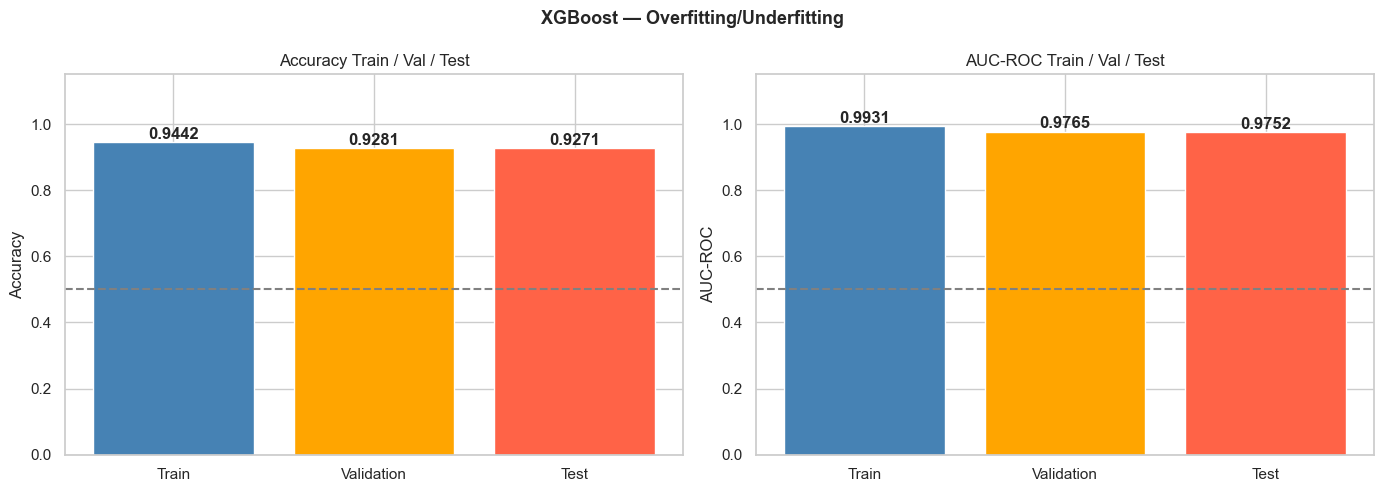

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Train', 'Validation', 'Test']

axes[0].bar(categories, [acc_train_xg, acc_val_xg, acc_test_xg],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy Train / Val / Test')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([acc_train_xg, acc_val_xg, acc_test_xg]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(categories, [auc_train_xg, auc_val_xg, auc_test_xg],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC-ROC Train / Val / Test')
axes[1].set_ylabel('AUC-ROC')
axes[1].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([auc_train_xg, auc_val_xg, auc_test_xg]):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('XGBoost — Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print_threshold_table(y_test, y_proba_xg, 'XGBoost')


XGBoost — Metriques par seuil
Seuil    Accuracy    Recall     Specificite    Precision    F1       TP     FP     FN     TN
-------------------------------------------------------------------------------------
0.50     0.9271      0.8606     0.9333         0.5451       0.6674   1463   1221   237    17079 <- Spec>=50%
0.40     0.9083      0.8971     0.9093         0.4790       0.6245   1525   1659   175    16641 <- Spec>=50%
0.30     0.8842      0.9276     0.8802         0.4184       0.5767   1577   2192   123    16108 <- Spec>=50%
0.20     0.8532      0.9535     0.8439         0.3621       0.5249   1621   2856   79     15444 <- Spec>=50%
0.10     0.8129      0.9729     0.7981         0.3092       0.4693   1654   3695   46     14605 <- Spec>=50%


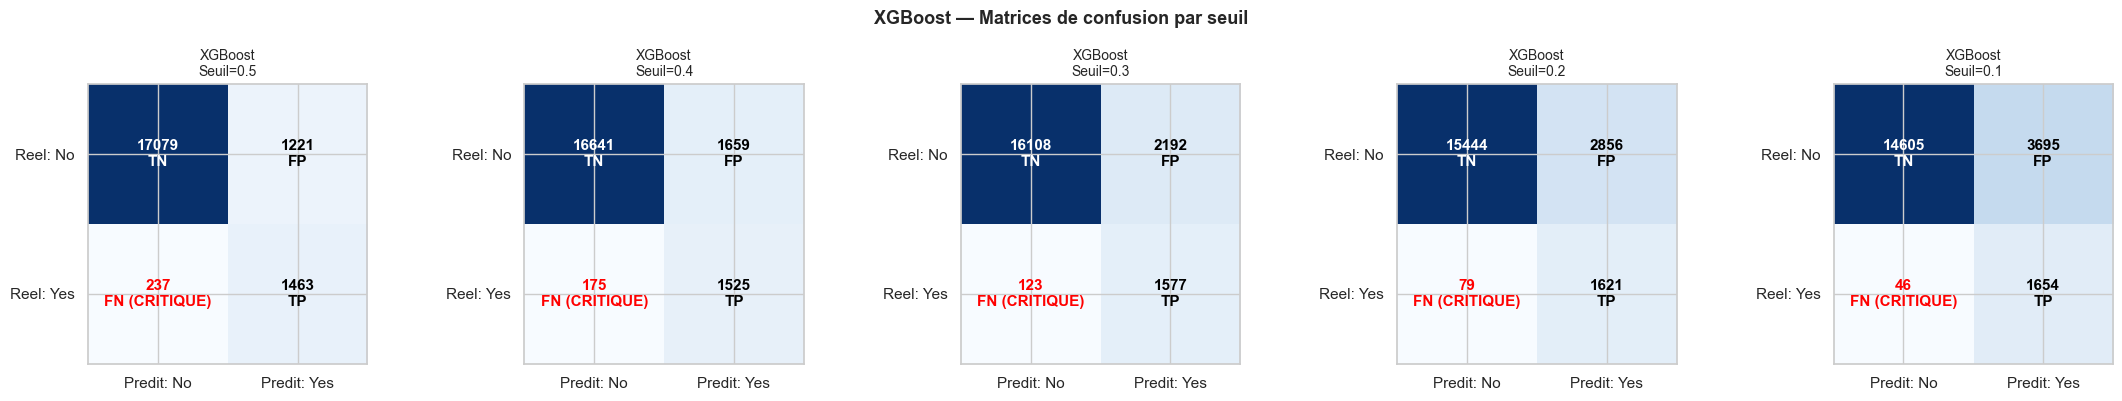

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j, thresh in enumerate(THRESHOLDS):
    plot_confusion_matrix_medical(y_test, y_proba_xg, thresh, 'XGBoost', axes[j])
plt.suptitle('XGBoost — Matrices de confusion par seuil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

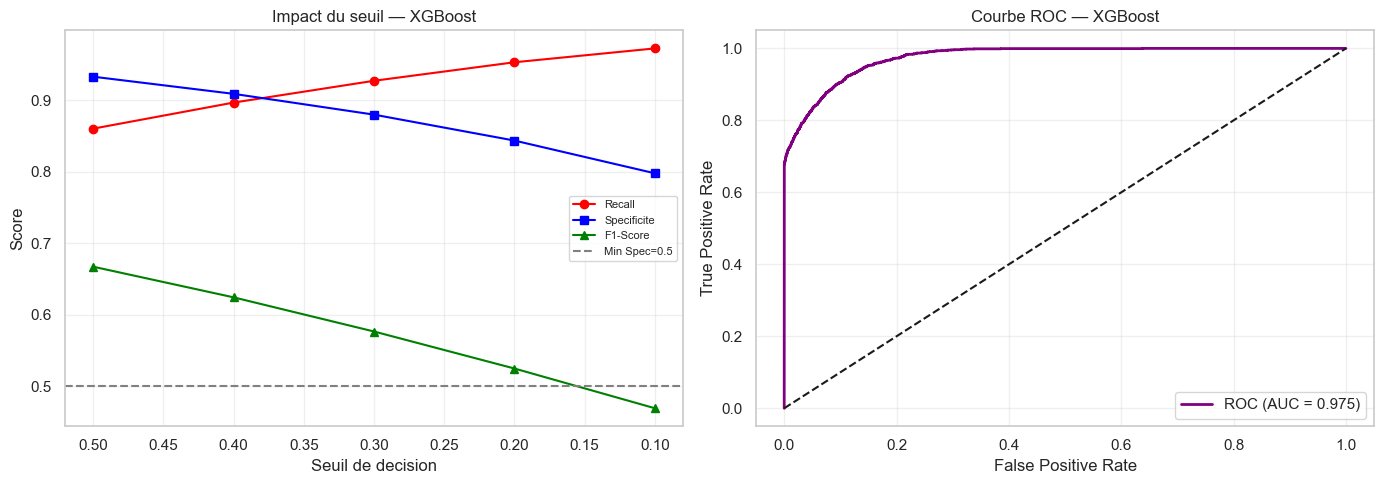

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_threshold_curves(y_test, y_proba_xg, 'XGBoost', axes[0])

fpr_xg, tpr_xg, _ = roc_curve(y_test, y_proba_xg)
axes[1].plot(fpr_xg, tpr_xg, color='purple', linewidth=2,
             label=f'ROC (AUC = {auc_test_xg:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — XGBoost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
best_thresh_xg, best_metrics_xg = find_best_threshold(y_test, y_proba_xg)
if best_thresh_xg:
    print(f'Meilleur seuil (Spec>={MIN_SPEC}) : {best_thresh_xg}')
    print(f'  Recall      = {best_metrics_xg["Recall"]:.4f}')
    print(f'  Specificite = {best_metrics_xg["Specificite"]:.4f}')
    print(f'  F1-Score    = {best_metrics_xg["F1"]:.4f}')
    print(f'  TP={best_metrics_xg["TP"]} | FN={best_metrics_xg["FN"]} (CRITIQUE) | FP={best_metrics_xg["FP"]} | TN={best_metrics_xg["TN"]}')
else:
    print('Aucun seuil ne satisfait Specificite >= 50%')
    best_thresh_xg  = 0.5
    best_metrics_xg = compute_metrics(y_test, y_proba_xg, 0.5)

Meilleur seuil (Spec>=0.5) : 0.1
  Recall      = 0.9729
  Specificite = 0.7981
  F1-Score    = 0.4693
  TP=1654 | FN=46 (CRITIQUE) | FP=3695 | TN=14605


---
## MODÈLE 4 : KNN (K-Nearest Neighbors)
Algorithme basé sur la proximité. k=5 voisins.

In [26]:
MODEL_NAME  = 'KNN'
model       = models[MODEL_NAME]
y_proba_knn = model.predict_proba(X_test)[:, 1]

auc_train_knn = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_val_knn   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
auc_test_knn  = roc_auc_score(y_test,  y_proba_knn)
acc_train_knn = accuracy_score(y_train, model.predict(X_train))
acc_val_knn   = accuracy_score(y_val,   model.predict(X_val))
acc_test_knn  = accuracy_score(y_test,  model.predict(X_test))

print('=' * 55)
print('KNN — Overfitting/Underfitting')
print('=' * 55)
print(f'Accuracy  : Train={acc_train_knn:.4f} | Val={acc_val_knn:.4f} | Test={acc_test_knn:.4f}')
print(f'AUC-ROC   : Train={auc_train_knn:.4f} | Val={auc_val_knn:.4f} | Test={auc_test_knn:.4f}')
print(f'Statut    : {overfitting_status(auc_train_knn, auc_test_knn)}')

KNN — Overfitting/Underfitting
Accuracy  : Train=0.9691 | Val=0.9628 | Test=0.9604
AUC-ROC   : Train=0.9889 | Val=0.9068 | Test=0.8984
Statut    : OK (ecart=0.090)


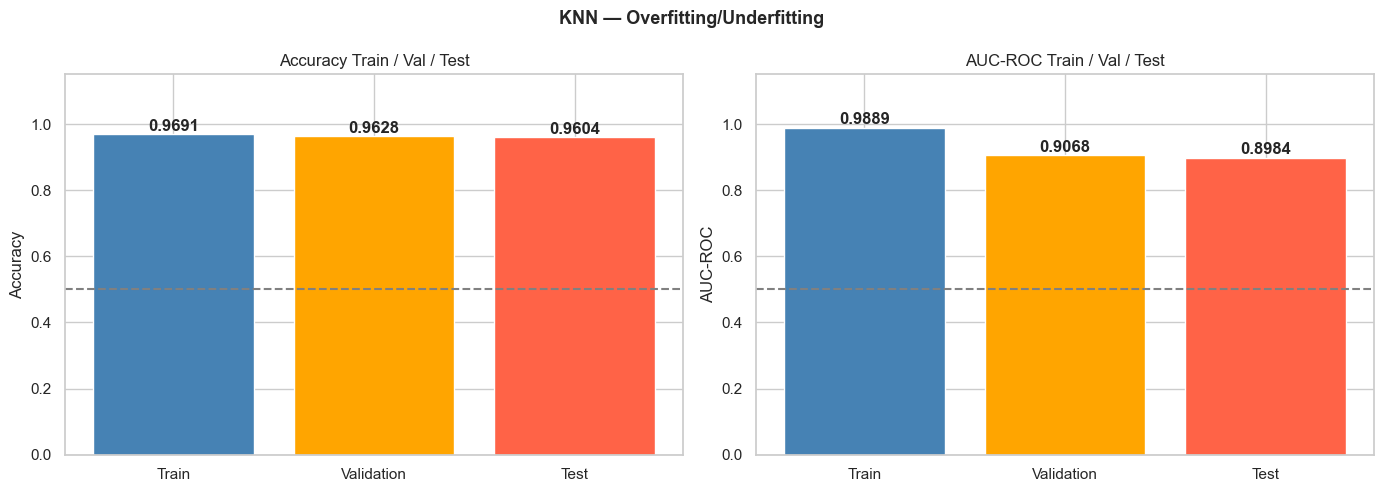

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Train', 'Validation', 'Test']

axes[0].bar(categories, [acc_train_knn, acc_val_knn, acc_test_knn],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy Train / Val / Test')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([acc_train_knn, acc_val_knn, acc_test_knn]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(categories, [auc_train_knn, auc_val_knn, auc_test_knn],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC-ROC Train / Val / Test')
axes[1].set_ylabel('AUC-ROC')
axes[1].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([auc_train_knn, auc_val_knn, auc_test_knn]):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('KNN — Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
print_threshold_table(y_test, y_proba_knn, 'KNN')


KNN — Metriques par seuil
Seuil    Accuracy    Recall     Specificite    Precision    F1       TP     FP     FN     TN
-------------------------------------------------------------------------------------
0.50     0.9604      0.6182     0.9921         0.8795       0.7261   1051   144    649    18156 <- Spec>=50%
0.40     0.9490      0.7106     0.9712         0.6963       0.7033   1208   527    492    17773 <- Spec>=50%
0.30     0.9490      0.7106     0.9712         0.6963       0.7033   1208   527    492    17773 <- Spec>=50%
0.20     0.8976      0.8324     0.9037         0.4454       0.5803   1415   1762   285    16538 <- Spec>=50%
0.10     0.8976      0.8324     0.9037         0.4454       0.5803   1415   1762   285    16538 <- Spec>=50%


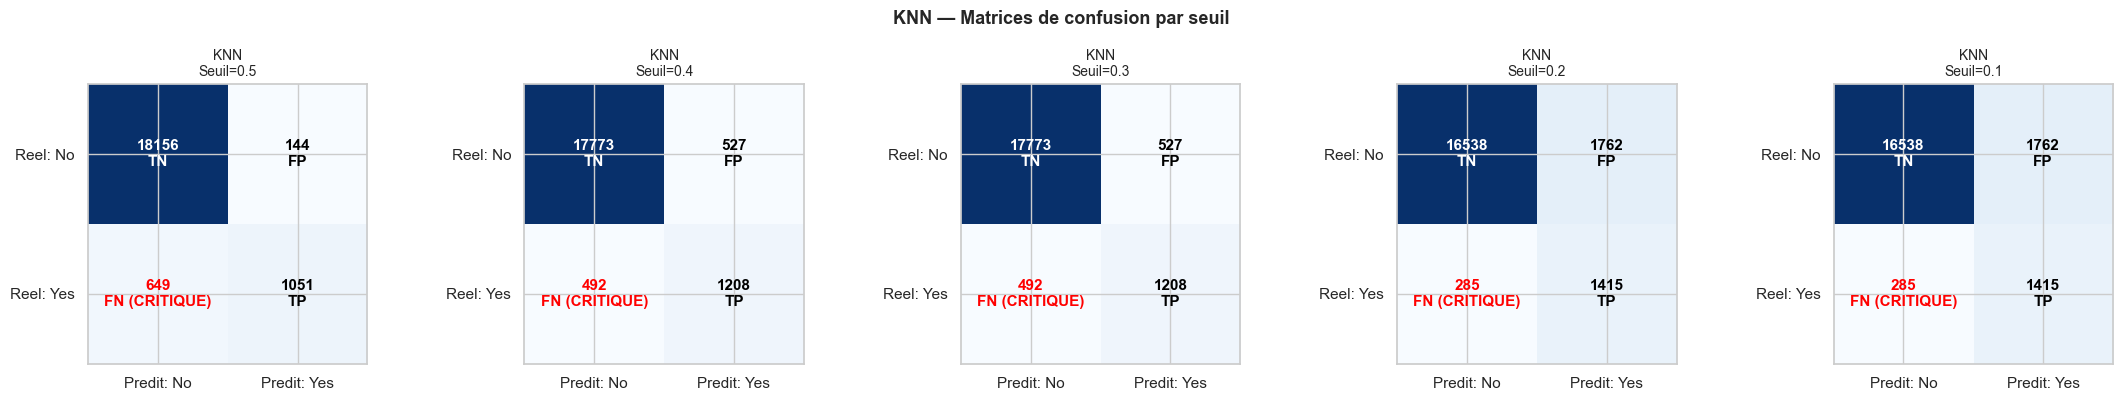

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j, thresh in enumerate(THRESHOLDS):
    plot_confusion_matrix_medical(y_test, y_proba_knn, thresh, 'KNN', axes[j])
plt.suptitle('KNN — Matrices de confusion par seuil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

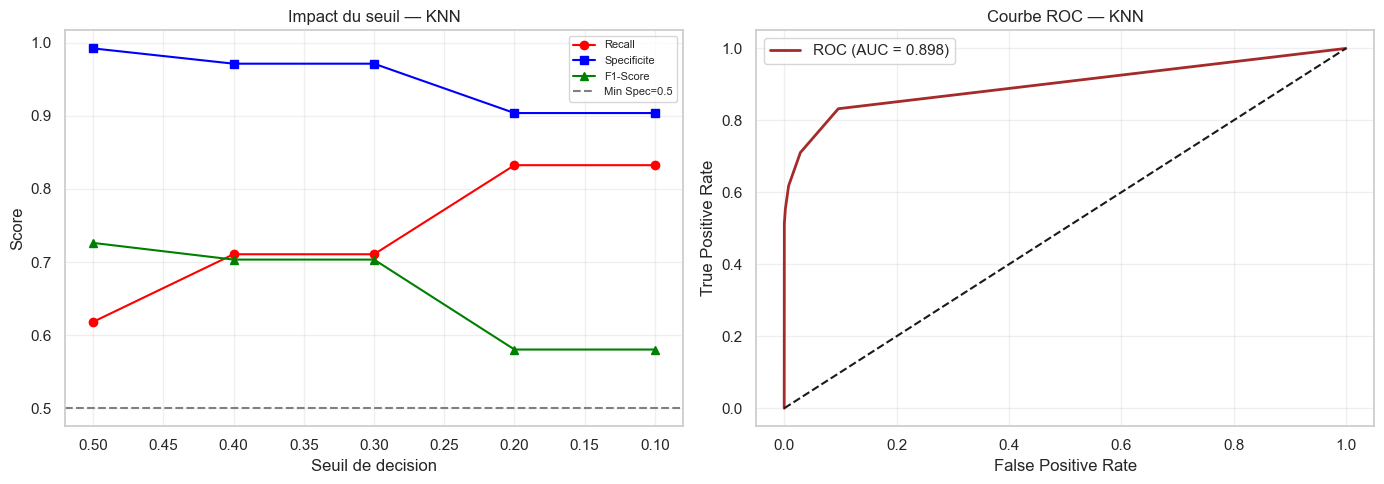

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_threshold_curves(y_test, y_proba_knn, 'KNN', axes[0])

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
axes[1].plot(fpr_knn, tpr_knn, color='brown', linewidth=2,
             label=f'ROC (AUC = {auc_test_knn:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — KNN')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
best_thresh_knn, best_metrics_knn = find_best_threshold(y_test, y_proba_knn)
if best_thresh_knn:
    print(f'Meilleur seuil (Spec>={MIN_SPEC}) : {best_thresh_knn}')
    print(f'  Recall      = {best_metrics_knn["Recall"]:.4f}')
    print(f'  Specificite = {best_metrics_knn["Specificite"]:.4f}')
    print(f'  F1-Score    = {best_metrics_knn["F1"]:.4f}')
    print(f'  TP={best_metrics_knn["TP"]} | FN={best_metrics_knn["FN"]} (CRITIQUE) | FP={best_metrics_knn["FP"]} | TN={best_metrics_knn["TN"]}')
else:
    print('Aucun seuil ne satisfait Specificite >= 50%')
    best_thresh_knn  = 0.5
    best_metrics_knn = compute_metrics(y_test, y_proba_knn, 0.5)

Meilleur seuil (Spec>=0.5) : 0.2
  Recall      = 0.8324
  Specificite = 0.9037
  F1-Score    = 0.5803
  TP=1415 | FN=285 (CRITIQUE) | FP=1762 | TN=16538


---
## MODÈLE 5 : Decision Tree
Arbre de décision. Très interprétable mais souvent sujet à l'overfitting.

In [32]:
MODEL_NAME = 'DecisionTree'
model      = models[MODEL_NAME]
y_proba_dt = model.predict_proba(X_test)[:, 1]

auc_train_dt = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_val_dt   = roc_auc_score(y_val,   model.predict_proba(X_val)[:, 1])
auc_test_dt  = roc_auc_score(y_test,  y_proba_dt)
acc_train_dt = accuracy_score(y_train, model.predict(X_train))
acc_val_dt   = accuracy_score(y_val,   model.predict(X_val))
acc_test_dt  = accuracy_score(y_test,  model.predict(X_test))

print('=' * 55)
print('DECISION TREE — Overfitting/Underfitting')
print('=' * 55)
print(f'Accuracy  : Train={acc_train_dt:.4f} | Val={acc_val_dt:.4f} | Test={acc_test_dt:.4f}')
print(f'AUC-ROC   : Train={auc_train_dt:.4f} | Val={auc_val_dt:.4f} | Test={auc_test_dt:.4f}')
print(f'Statut    : {overfitting_status(auc_train_dt, auc_test_dt)}')

DECISION TREE — Overfitting/Underfitting
Accuracy  : Train=0.9990 | Val=0.9549 | Test=0.9532
AUC-ROC   : Train=1.0000 | Val=0.8546 | Test=0.8543
Statut    : OVERFITTING (ecart=0.146)


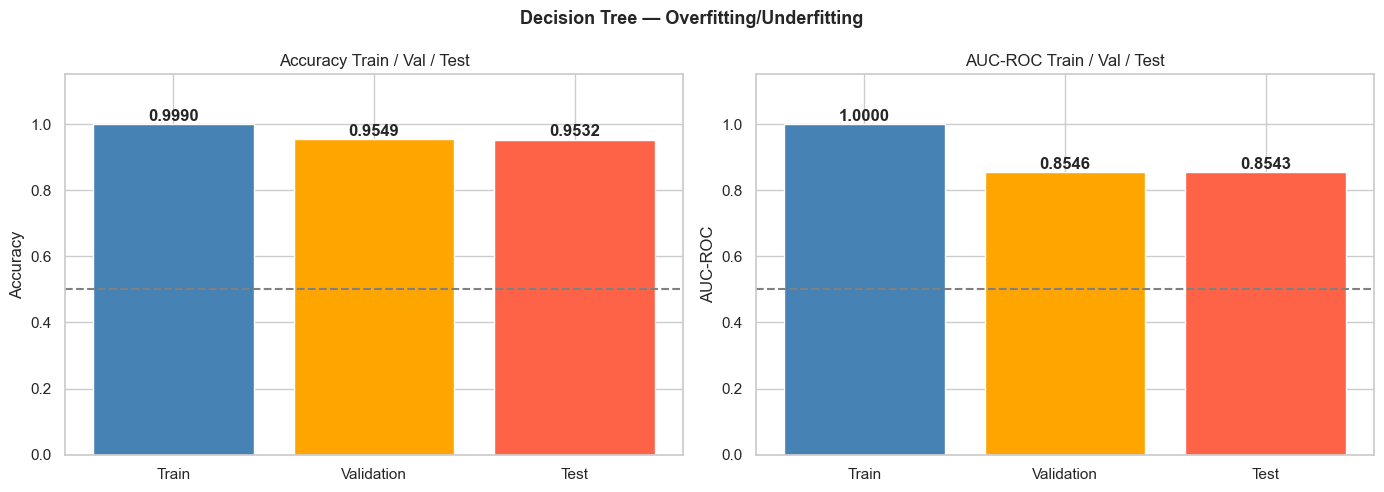

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Train', 'Validation', 'Test']

axes[0].bar(categories, [acc_train_dt, acc_val_dt, acc_test_dt],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy Train / Val / Test')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([acc_train_dt, acc_val_dt, acc_test_dt]):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(categories, [auc_train_dt, auc_val_dt, auc_test_dt],
            color=['steelblue','orange','tomato'], edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('AUC-ROC Train / Val / Test')
axes[1].set_ylabel('AUC-ROC')
axes[1].axhline(0.5, color='gray', linestyle='--')
for i, v in enumerate([auc_train_dt, auc_val_dt, auc_test_dt]):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Decision Tree — Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
print_threshold_table(y_test, y_proba_dt, 'Decision Tree')


Decision Tree — Metriques par seuil
Seuil    Accuracy    Recall     Specificite    Precision    F1       TP     FP     FN     TN
-------------------------------------------------------------------------------------
0.50     0.9532      0.7341     0.9735         0.7201       0.7271   1248   485    452    17815 <- Spec>=50%
0.40     0.9532      0.7341     0.9735         0.7201       0.7271   1248   485    452    17815 <- Spec>=50%
0.30     0.9532      0.7341     0.9735         0.7201       0.7271   1248   485    452    17815 <- Spec>=50%
0.20     0.9532      0.7341     0.9735         0.7201       0.7271   1248   485    452    17815 <- Spec>=50%
0.10     0.9532      0.7341     0.9735         0.7201       0.7271   1248   485    452    17815 <- Spec>=50%


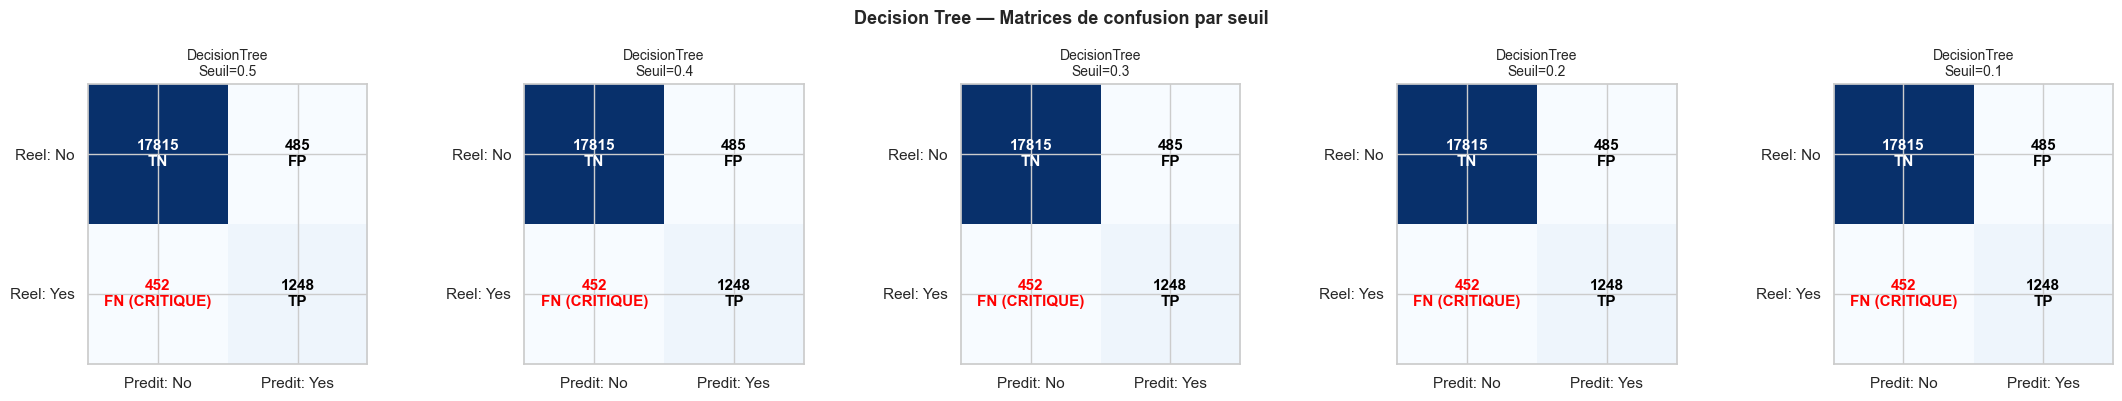

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for j, thresh in enumerate(THRESHOLDS):
    plot_confusion_matrix_medical(y_test, y_proba_dt, thresh, 'DecisionTree', axes[j])
plt.suptitle('Decision Tree — Matrices de confusion par seuil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

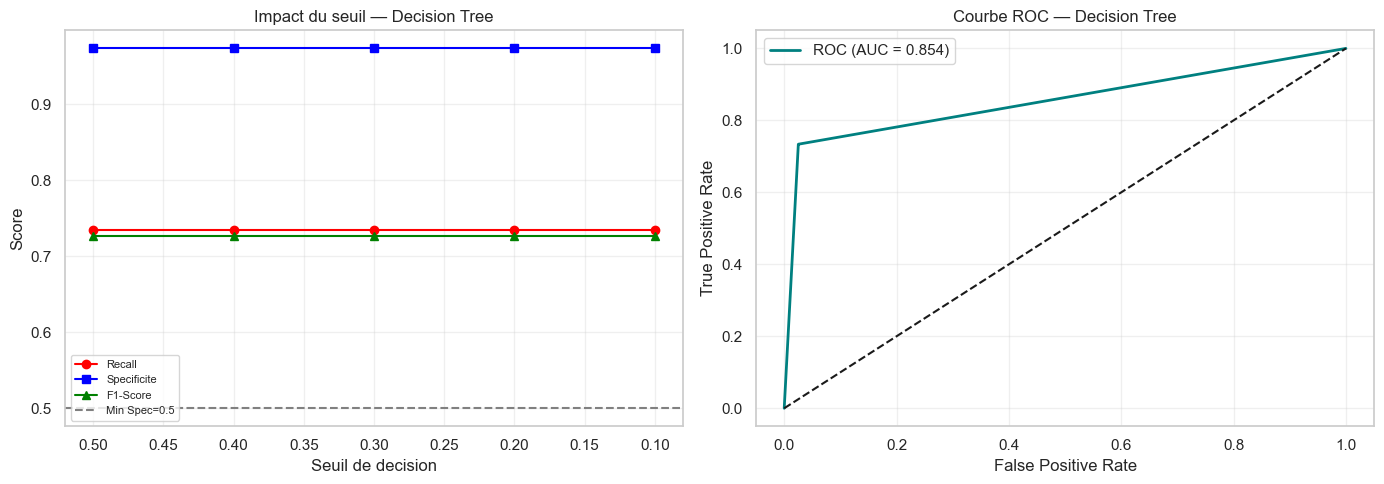

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_threshold_curves(y_test, y_proba_dt, 'Decision Tree', axes[0])

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
axes[1].plot(fpr_dt, tpr_dt, color='teal', linewidth=2,
             label=f'ROC (AUC = {auc_test_dt:.3f})')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — Decision Tree')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
best_thresh_dt, best_metrics_dt = find_best_threshold(y_test, y_proba_dt)
if best_thresh_dt:
    print(f'Meilleur seuil (Spec>={MIN_SPEC}) : {best_thresh_dt}')
    print(f'  Recall      = {best_metrics_dt["Recall"]:.4f}')
    print(f'  Specificite = {best_metrics_dt["Specificite"]:.4f}')
    print(f'  F1-Score    = {best_metrics_dt["F1"]:.4f}')
    print(f'  TP={best_metrics_dt["TP"]} | FN={best_metrics_dt["FN"]} (CRITIQUE) | FP={best_metrics_dt["FP"]} | TN={best_metrics_dt["TN"]}')
else:
    print('Aucun seuil ne satisfait Specificite >= 50%')
    best_thresh_dt  = 0.5
    best_metrics_dt = compute_metrics(y_test, y_proba_dt, 0.5)

Meilleur seuil (Spec>=0.5) : 0.5
  Recall      = 0.7341
  Specificite = 0.9735
  F1-Score    = 0.7271
  TP=1248 | FN=452 (CRITIQUE) | FP=485 | TN=17815


---
## COMPARAISON FINALE — Tous les modèles
Comparaison graphique et numérique. Sélection du meilleur modèle selon :
- **Recall maximum**
- **Specificité ≥ 50%**
- **Pas d'overfitting (écart AUC train-test ≤ 0.1)**

In [38]:
# Synthese de tous les resultats
noms       = ['LogisticRegression','RandomForest','XGBoost','KNN','DecisionTree']
probas     = [y_proba_lr, y_proba_rf, y_proba_xg, y_proba_knn, y_proba_dt]
auc_trains = [auc_train_lr, auc_train_rf, auc_train_xg, auc_train_knn, auc_train_dt]
auc_vals   = [auc_val_lr,   auc_val_rf,   auc_val_xg,   auc_val_knn,   auc_val_dt]
auc_tests  = [auc_test_lr,  auc_test_rf,  auc_test_xg,  auc_test_knn,  auc_test_dt]
acc_trains = [acc_train_lr, acc_train_rf, acc_train_xg, acc_train_knn, acc_train_dt]
acc_vals   = [acc_val_lr,   acc_val_rf,   acc_val_xg,   acc_val_knn,   acc_val_dt]
acc_tests  = [acc_test_lr,  acc_test_rf,  acc_test_xg,  acc_test_knn,  acc_test_dt]
best_threshs  = [best_thresh_lr, best_thresh_rf, best_thresh_xg, best_thresh_knn, best_thresh_dt]
best_metrics_all = [best_metrics_lr, best_metrics_rf, best_metrics_xg, best_metrics_knn, best_metrics_dt]

summary = []
for i, nom in enumerate(noms):
    ecart  = auc_trains[i] - auc_tests[i]
    statut = 'OVERFIT' if ecart > OVERFIT_SEUIL else ('UNDERFIT' if auc_tests[i] < 0.6 else 'OK')
    m = best_metrics_all[i]
    summary.append({
        'Modele':        nom,
        'AUC Train':     round(auc_trains[i], 4),
        'AUC Val':       round(auc_vals[i],   4),
        'AUC Test':      round(auc_tests[i],  4),
        'Ecart AUC':     round(ecart, 4),
        'Statut':        statut,
        'Meilleur Seuil': best_threshs[i],
        'Recall':        m['Recall'],
        'Specificite':   m['Specificite'],
        'F1':            m['F1'],
        'TP':            m['TP'],
        'FN (critique)': m['FN'],
    })

df_summary = pd.DataFrame(summary)
display(df_summary.sort_values('Recall', ascending=False))

,Modele,AUC Train,AUC Val,AUC Test,Ecart AUC,Statut,Meilleur Seuil,Recall,Specificite,F1,TP,FN (critique)
0,LogisticRegression,0.9620,0.9629,0.9629,-0.0009,OK,0.1,0.9871,0.6377,0.3353,1678,22
2,XGBoost,0.9931,0.9765,0.9752,0.0180,OK,0.1,0.9729,0.7981,0.4693,1654,46
1,RandomForest,1.0000,0.9645,0.9612,0.0388,OK,0.1,0.8765,0.9138,0.6250,1490,210
3,KNN,0.9889,0.9068,0.8984,0.0905,OK,0.2,0.8324,0.9037,0.5803,1415,285
4,DecisionTree,1.0000,0.8546,0.8543,0.1457,OVERFIT,0.5,0.7341,0.9735,0.7271,1248,452


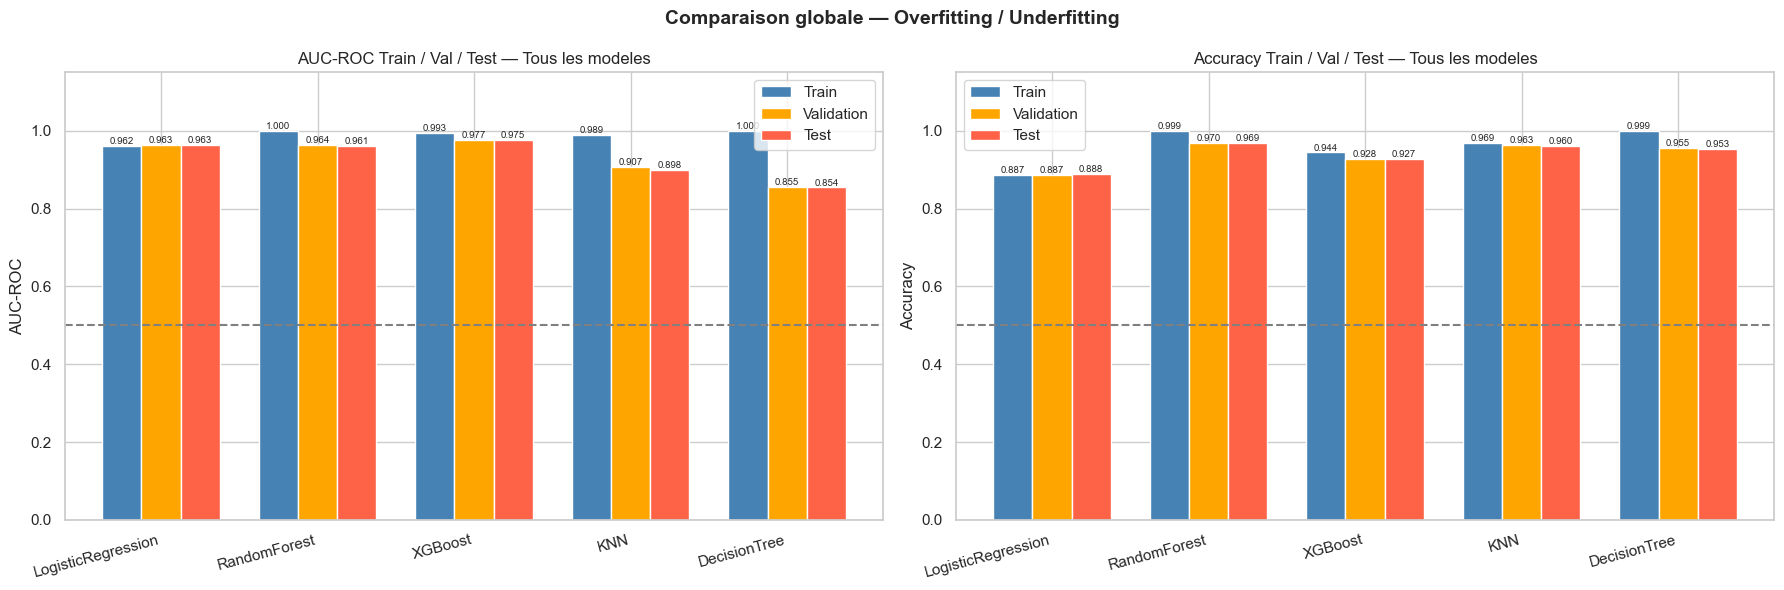

In [39]:
# Graphique 1 : AUC Train/Val/Test tous les modeles
x  = np.arange(len(noms))
w  = 0.25
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(x - w, auc_trains, w, label='Train',      color='steelblue', edgecolor='white')
axes[0].bar(x,     auc_vals,   w, label='Validation', color='orange',    edgecolor='white')
axes[0].bar(x + w, auc_tests,  w, label='Test',       color='tomato',    edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(noms, rotation=15, ha='right')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC Train / Val / Test — Tous les modeles')
axes[0].axhline(0.5, color='gray', linestyle='--')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7)

axes[1].bar(x - w, acc_trains, w, label='Train',      color='steelblue', edgecolor='white')
axes[1].bar(x,     acc_vals,   w, label='Validation', color='orange',    edgecolor='white')
axes[1].bar(x + w, acc_tests,  w, label='Test',       color='tomato',    edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(noms, rotation=15, ha='right')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Train / Val / Test — Tous les modeles')
axes[1].axhline(0.5, color='gray', linestyle='--')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7)

plt.suptitle('Comparaison globale — Overfitting / Underfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

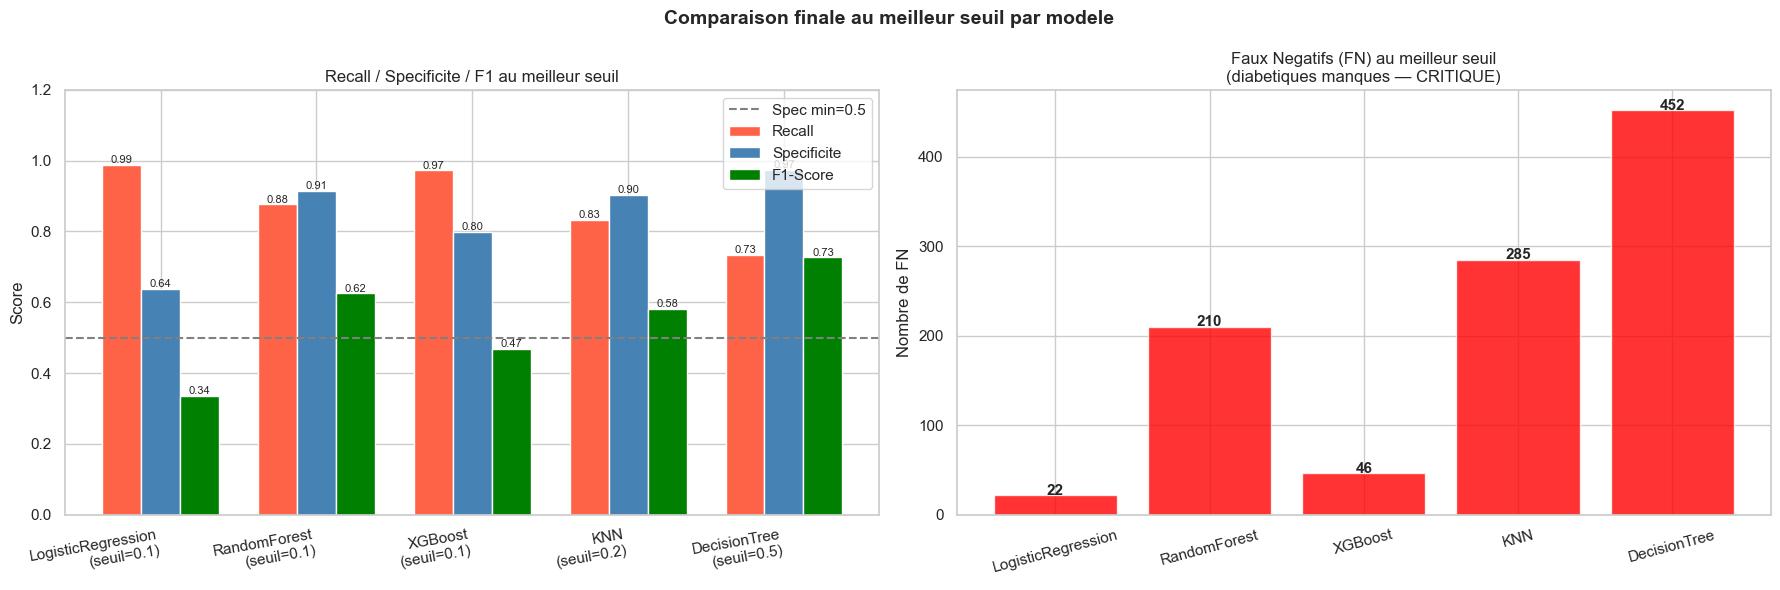

In [40]:
# Graphique 2 : Recall / Specificite / F1 au meilleur seuil
recalls  = [m['Recall']      for m in best_metrics_all]
specs    = [m['Specificite'] for m in best_metrics_all]
f1s      = [m['F1']          for m in best_metrics_all]
fns      = [m['FN']          for m in best_metrics_all]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(noms))
w = 0.25

axes[0].bar(x - w, recalls, w, label='Recall',      color='tomato',    edgecolor='white')
axes[0].bar(x,     specs,   w, label='Specificite', color='steelblue', edgecolor='white')
axes[0].bar(x + w, f1s,     w, label='F1-Score',    color='green',     edgecolor='white')
axes[0].axhline(MIN_SPEC, color='gray', linestyle='--', label=f'Spec min={MIN_SPEC}')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{n}\n(seuil={t})' for n,t in zip(noms,best_threshs)],
                         rotation=10, ha='right')
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel('Score')
axes[0].set_title('Recall / Specificite / F1 au meilleur seuil')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8)

# Faux Negatifs
axes[1].bar(noms, fns, color='red', edgecolor='white', alpha=0.8)
axes[1].set_title('Faux Negatifs (FN) au meilleur seuil\n(diabetiques manques — CRITIQUE)')
axes[1].set_ylabel('Nombre de FN')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(fns):
    axes[1].text(i, v+0.3, str(v), ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Comparaison finale au meilleur seuil par modele', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

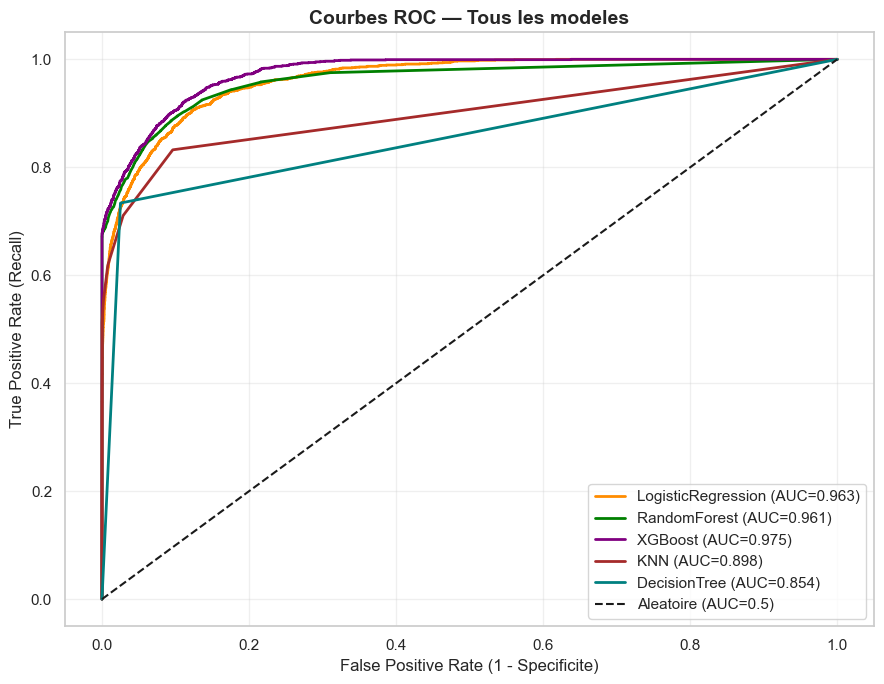

In [41]:
# Graphique 3 : Courbes ROC superposees
colors = ['darkorange', 'green', 'purple', 'brown', 'teal']
fprs   = [fpr_lr, fpr_rf, fpr_xg, fpr_knn, fpr_dt]
tprs   = [tpr_lr, tpr_rf, tpr_xg, tpr_knn, tpr_dt]

plt.figure(figsize=(9, 7))
for i, nom in enumerate(noms):
    plt.plot(fprs[i], tprs[i], color=colors[i], linewidth=2,
             label=f'{nom} (AUC={auc_tests[i]:.3f})')
plt.plot([0,1],[0,1],'k--', label='Aleatoire (AUC=0.5)')
plt.xlabel('False Positive Rate (1 - Specificite)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbes ROC — Tous les modeles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

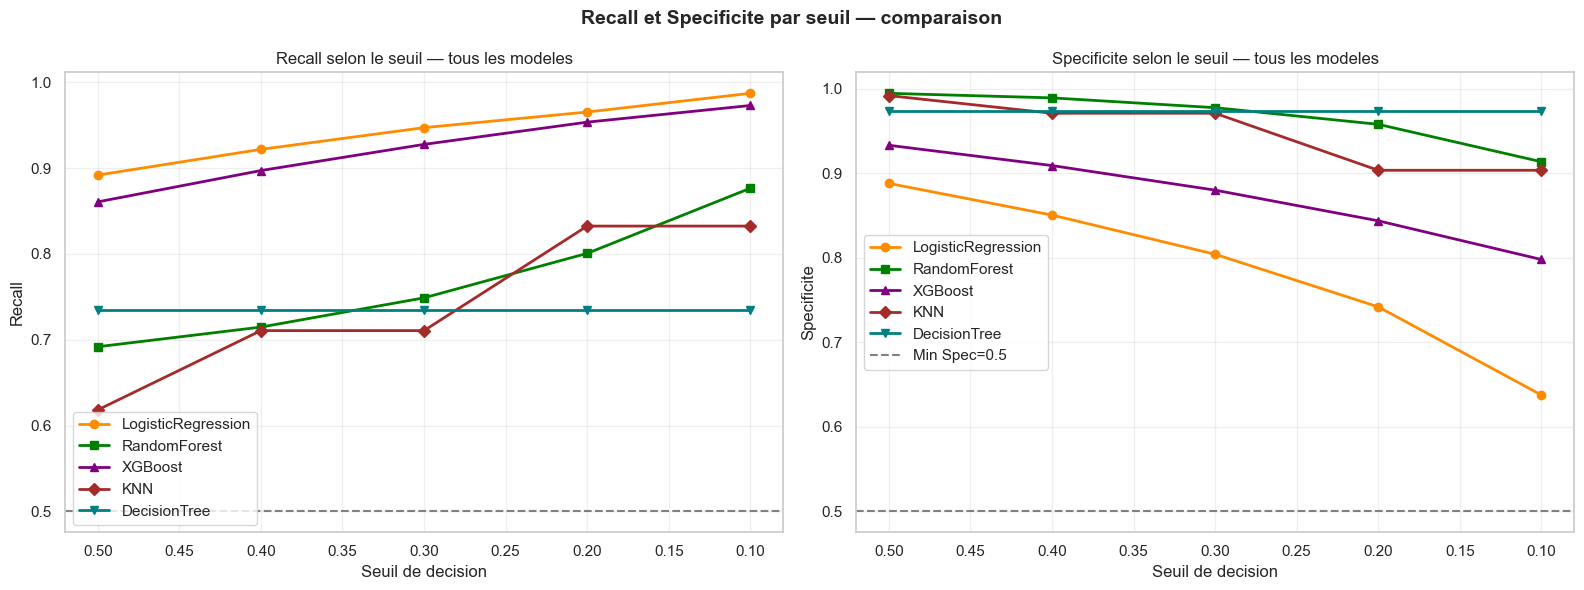

In [42]:
# Graphique 4 : Recall et Specificite par seuil pour tous les modeles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_map = {'LogisticRegression':'darkorange','RandomForest':'green',
              'XGBoost':'purple','KNN':'brown','DecisionTree':'teal'}
markers    = ['o','s','^','D','v']

all_probas = {'LogisticRegression':y_proba_lr,'RandomForest':y_proba_rf,
              'XGBoost':y_proba_xg,'KNN':y_proba_knn,'DecisionTree':y_proba_dt}

for i, nom in enumerate(noms):
    yp = all_probas[nom]
    rec_list  = [compute_metrics(y_test, yp, t)['Recall']      for t in THRESHOLDS]
    spec_list = [compute_metrics(y_test, yp, t)['Specificite'] for t in THRESHOLDS]
    axes[0].plot(THRESHOLDS, rec_list,  marker=markers[i], color=colors_map[nom],
                 linewidth=2, label=nom)
    axes[1].plot(THRESHOLDS, spec_list, marker=markers[i], color=colors_map[nom],
                 linewidth=2, label=nom)

axes[0].axhline(0.5, color='gray', linestyle='--')
axes[0].set_title('Recall selon le seuil — tous les modeles')
axes[0].set_xlabel('Seuil de decision')
axes[0].set_ylabel('Recall')
axes[0].invert_xaxis()
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(MIN_SPEC, color='gray', linestyle='--', label=f'Min Spec={MIN_SPEC}')
axes[1].set_title('Specificite selon le seuil — tous les modeles')
axes[1].set_xlabel('Seuil de decision')
axes[1].set_ylabel('Specificite')
axes[1].invert_xaxis()
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Recall et Specificite par seuil — comparaison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# Tableau final comparatif
print('=' * 90)
print('TABLEAU COMPARATIF FINAL — MEILLEUR SEUIL PAR MODELE')
print('=' * 90)
print(f"{'Modele':<22} {'Seuil':<8} {'AUC Test':<11} {'Recall':<10} {'Specificite':<14} {'F1':<8} {'FN':>4} {'Statut'}")
print('-' * 90)
for i, nom in enumerate(noms):
    m = best_metrics_all[i]
    ecart  = auc_trains[i] - auc_tests[i]
    statut = 'OVERFIT' if ecart > OVERFIT_SEUIL else ('UNDERFIT' if auc_tests[i] < 0.6 else 'OK')
    print(f"{nom:<22} {best_threshs[i]:<8.2f} {auc_tests[i]:<11.4f} {m['Recall']:<10.4f} "
          f"{m['Specificite']:<14.4f} {m['F1']:<8.4f} {m['FN']:>4}  {statut}")
print('=' * 90)

TABLEAU COMPARATIF FINAL — MEILLEUR SEUIL PAR MODELE
Modele                 Seuil    AUC Test    Recall     Specificite    F1         FN Statut
------------------------------------------------------------------------------------------
LogisticRegression     0.10     0.9629      0.9871     0.6377         0.3353     22  OK
RandomForest           0.10     0.9612      0.8765     0.9138         0.6250    210  OK
XGBoost                0.10     0.9752      0.9729     0.7981         0.4693     46  OK
KNN                    0.20     0.8984      0.8324     0.9037         0.5803    285  OK
DecisionTree           0.50     0.8543      0.7341     0.9735         0.7271    452  OVERFIT


In [44]:
# Selection automatique du meilleur modele
print('=' * 65)
print('SELECTION DU MEILLEUR MODELE')
print('Criteres :')
print(f'  1. Specificite >= {MIN_SPEC}')
print(f'  2. Pas d\'overfitting (ecart AUC <= {OVERFIT_SEUIL})')
print(f'  3. Recall maximum parmi les candidats')
print('=' * 65)

candidats = []
for i, nom in enumerate(noms):
    m     = best_metrics_all[i]
    ecart = auc_trains[i] - auc_tests[i]
    if m['Specificite'] >= MIN_SPEC and ecart <= OVERFIT_SEUIL:
        candidats.append((nom, best_threshs[i], m, auc_tests[i], ecart))

if candidats:
    candidats.sort(key=lambda x: x[2]['Recall'], reverse=True)
    meilleur = candidats[0]
    nom_m, seuil_m, metrics_m, auc_m, ecart_m = meilleur
    print(f'\nMEILLEUR MODELE : {nom_m}')
    print(f'Seuil retenu    : {seuil_m}')
    print(f'AUC Test        : {auc_m:.4f}')
    print(f'Recall          : {metrics_m["Recall"]:.4f}')
    print(f'Specificite     : {metrics_m["Specificite"]:.4f}')
    print(f'F1-Score        : {metrics_m["F1"]:.4f}')
    print(f'Ecart AUC       : {ecart_m:.4f}  (pas d\'overfitting)')
    print(f'TP={metrics_m["TP"]} | FN={metrics_m["FN"]} (diabetiques manques) | FP={metrics_m["FP"]} | TN={metrics_m["TN"]}')
    if len(candidats) > 1:
        print(f'\nAutres candidats valides :')
        for c in candidats[1:]:
            print(f'  {c[0]:<22} Recall={c[2]["Recall"]:.4f} | Spec={c[2]["Specificite"]:.4f} | Seuil={c[1]}')
else:
    print('\nAucun modele ne satisfait tous les criteres.')
    print('Meilleur AUC Test sans contrainte :')
    idx = int(np.argmax(auc_tests))
    print(f'  {noms[idx]} — AUC={auc_tests[idx]:.4f}')
print('\n' + '=' * 65)

SELECTION DU MEILLEUR MODELE
Criteres :
  1. Specificite >= 0.5
  2. Pas d'overfitting (ecart AUC <= 0.1)
  3. Recall maximum parmi les candidats

MEILLEUR MODELE : LogisticRegression
Seuil retenu    : 0.1
AUC Test        : 0.9629
Recall          : 0.9871
Specificite     : 0.6377
F1-Score        : 0.3353
Ecart AUC       : -0.0009  (pas d'overfitting)
TP=1678 | FN=22 (diabetiques manques) | FP=6631 | TN=11669

Autres candidats valides :
  XGBoost                Recall=0.9729 | Spec=0.7981 | Seuil=0.1
  RandomForest           Recall=0.8765 | Spec=0.9138 | Seuil=0.1
  KNN                    Recall=0.8324 | Spec=0.9037 | Seuil=0.2

